In [1]:
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
# root_proj = Path("/Users/yk/Documents/Projects/Pre-PhD")
# root_proj = Path("/Users/VERTPOM-UPJV/Documents/Banque_de_l'energie_V2/Data_prediction_K/Pre-PhD")
root_proj = Path("/Users/alesk/Documents/Git-repo/Pre-PhD")
# root_proj = Path("D:/GIT-REPO/Pre-PhD")
if str(root_proj/"src") not in sys.path:
    sys.path.append(str(root_proj/"src"))

In [2]:

df = pd.read_excel(root_proj / "DATA_SYSTEM_LIDL/Responsive Utility meter.xlsx", sheet_name=["2022","2023"], skiprows=1)
year = "2022"

In [17]:
df_act = df[year]
df_act 

,Date,0_ ELEC : Eolien auto-consommé (159),0_Compteur ELEC: Production PV auto-consommée,0_EAU : RIA (17),0_EAU : Total fournisseur (mesuré) (1),0_ELEC : Consommation SPM (Total Mesuré + PV) (96),0_ELEC : Photovoltaïque auto-consommé (170),0_ELEC : Total Fournisseur mesuré (06),1_ELEC : Eclairage extérieur (43),1_ELEC : Eclairage intérieur (49),...,3_ELEC: Bacs négatifs / Vitrines surgelées (84),3_ELEC: Bacs positifs / Vitrines VVP (83),4_ELEC : Fours total (91),6_ELEC : Eau chaude sanitaire publique (141),7_ELEC : Prise de courant (SDV+Boulangerie) (123 + 124),7_ELEC : Prises de courant (SDV) (123),8_ELEC : Bornes électriques (97),c_gen,Date_utc,offset
0,2023-01-01 01:00,0.0,0.0,0.0,0.000,28.00,0.0,29.40,0.20,0.48,...,4.28,2.96,0.04,0.00,0.32,0.32,0.68,29.40,2023-01-01 00:00:00,1.0
1,2023-01-01 01:15,0.0,0.0,0.0,0.008,29.32,0.0,29.20,0.12,0.64,...,4.24,3.68,0.08,0.00,0.28,0.28,0.08,29.20,2023-01-01 00:15:00,1.0
2,2023-01-01 01:30,0.0,0.0,0.0,0.000,29.28,0.0,30.32,0.12,0.44,...,4.24,2.92,0.04,0.00,0.28,0.28,0.08,30.32,2023-01-01 00:30:00,1.0
3,2023-01-01 01:45,0.0,0.0,0.0,0.000,30.60,0.0,29.72,0.16,0.48,...,4.04,2.52,0.04,0.00,0.32,0.32,0.08,29.72,2023-01-01 00:45:00,1.0
4,2023-01-01 02:00,0.0,0.0,0.0,0.000,28.20,0.0,28.24,0.12,0.48,...,3.68,2.60,0.04,0.24,0.28,0.28,0.08,28.24,2023-01-01 01:00:00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34940,2023-12-31 00:00,0.0,0.0,0.0,0.580,25.56,0.0,26.12,0.08,0.60,...,3.56,2.72,0.08,0.20,0.48,0.48,0.12,26.12,2023-12-30 23:00:00,1.0
34941,2023-12-31 00:15,0.0,0.0,0.0,0.188,23.40,0.0,23.48,0.08,0.56,...,3.04,3.00,0.04,0.00,0.40,0.40,0.08,23.48,2023-12-30 23:15:00,1.0
34942,2023-12-31 00:30,0.0,0.0,0.0,0.012,24.12,0.0,23.56,0.08,0.56,...,4.16,2.60,0.04,0.00,0.36,0.36,0.08,23.56,2023-12-30 23:30:00,1.0
34943,2023-12-31 00:45,0.0,0.0,0.0,0.016,24.52,0.0,24.68,0.12,0.60,...,3.08,3.52,0.04,0.36,0.40,0.40,0.08,24.68,2023-12-30 23:45:00,1.0


In [18]:
df_act['c_gen'] = df_act["0_ELEC : Total Fournisseur mesuré (06)"]  
df_act["Date_utc"] = pd.to_datetime(
    df_act["Date"],
    format="%Y-%m-%d %H:%M"
)-pd.Timedelta(hours=1) 

df_act['offset'] = (df_act["Date_utc"].dt.tz_localize("UTC").dt.tz_convert("Europe/Paris").dt.tz_localize(None) - df_act["Date_utc"]).dt.total_seconds()//3600
df_act.drop(columns=["Date"], inplace=True)
df_act = df_act.rename(columns={"Date_utc":"Date"})

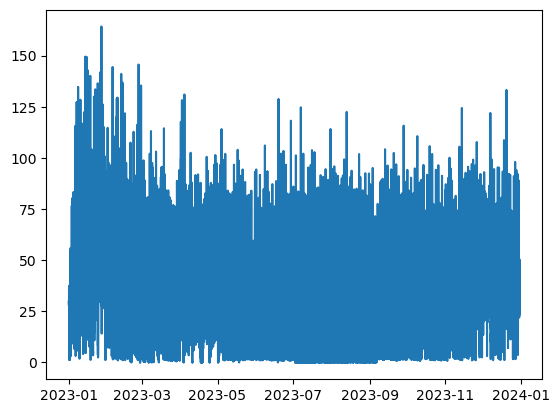

In [20]:
plt.plot(df_act.Date.dt.tz_localize(None), df_act['c_gen'])


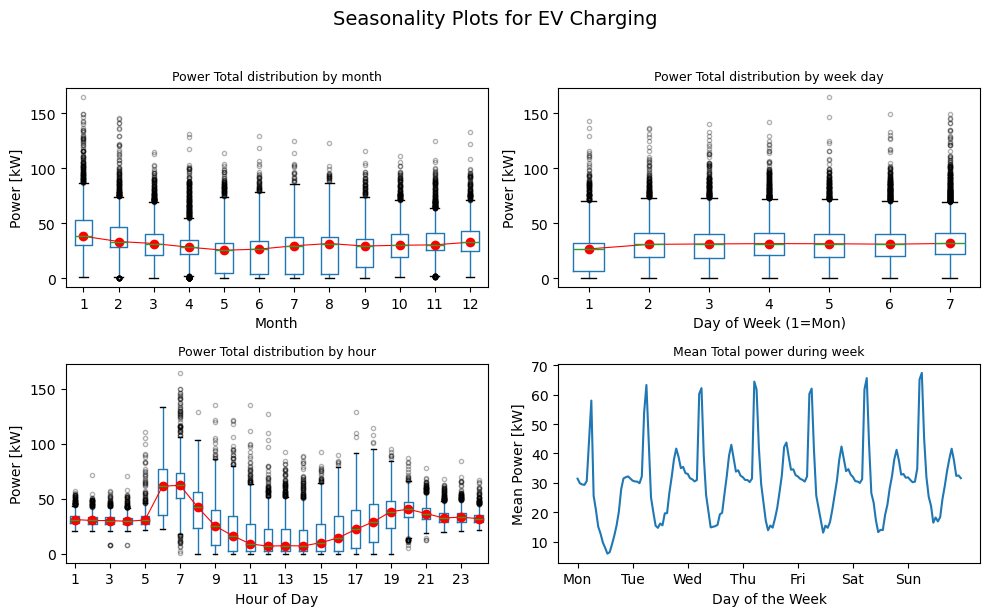

In [23]:
# Assuming df_ev is your dataframe from previous cells

fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey=False)
axs = axs.ravel()

# 1. Users distribution by month
df_act['month'] = df_act['Date'].dt.month  # Added .dt
df_act.boxplot(column='c_gen', by='month', ax=axs[0], flierprops={'markersize': 3, 'alpha': 0.3})
df_act.groupby('month')['c_gen'].median().plot(style='o-', linewidth=0.8, ax=axs[0], color='red')
axs[0].set_ylabel('Power [kW]') # Standardized label
axs[0].set_xlabel('Month')
axs[0].set_title('Power Total distribution by month', fontsize=9)

# 2. Users distribution by week day
df_act['week_day'] = df_act['Date'].dt.dayofweek + 1  # Added .dt and changed to dayofweek
df_act.boxplot(column='c_gen', by='week_day', ax=axs[1], flierprops={'markersize': 3, 'alpha': 0.3})
df_act.groupby('week_day')['c_gen'].median().plot(style='o-', linewidth=0.8, ax=axs[1], color='red')
axs[1].set_ylabel('Power [kW]')
axs[1].set_xlabel('Day of Week (1=Mon)')
axs[1].set_title('Power Total distribution by week day', fontsize=9)

# 3. Users distribution by the hour of the day
df_act['hour_day'] = df_act['Date'].dt.hour + 1  # Added .dt
df_act.boxplot(column='c_gen', by='hour_day', ax=axs[2], flierprops={'markersize': 3, 'alpha': 0.3})
df_act.groupby('hour_day')['c_gen'].median().plot(style='o-', linewidth=0.8, ax=axs[2], color='red')
axs[2].set_ylabel('Power [kW]')
axs[2].set_xlabel('Hour of Day')
axs[2].set_title('Power Total distribution by hour', fontsize=9)
axs[2].set_xticks(range(1, 25, 2))

# 4. Users distribution by week day and hour of the day
mean_day_hour = df_act.groupby(["week_day", "hour_day"])["c_gen"].mean()
# Reset index to make plotting a continuous line easier
mean_day_hour.values 
axs[3].plot(mean_day_hour.values) # Plotting the raw values as a continuous line
axs[3].set(
    title       = "Mean Total power during week",
    xticks      = [i * 24 for i in range(7)],
    xticklabels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel      = "Day of the Week",
    ylabel      = "Mean Power [kW]" # Corrected label
)
axs[3].title.set_size(9)

# Clean up layout and titles
plt.suptitle("") # Clears the automatic pandas boxplot title
fig.suptitle("Seasonality Plots for EV Charging", fontsize=14, y=1.02)
fig.tight_layout()
plt.savefig("seasonality_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()

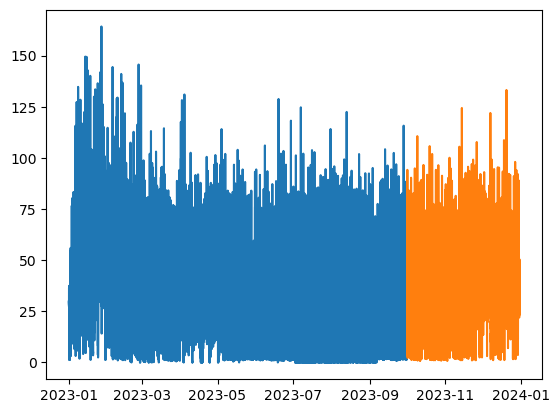

In [26]:
initial = df_act.index[df_act['Date'] == pd.Timestamp('2023-10-01 01:00:00', tz='Europe/Paris').tz_convert("UTC").tz_localize(None)][0]

df_train = df_act.iloc[:initial]
df_test = df_act.iloc[initial:]
plt.plot(df_train.Date.dt.tz_localize(None), df_train['c_gen'], label='Train')
plt.plot(df_test.Date.dt.tz_localize(None), df_test['c_gen'], label='Test')




In [27]:
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
days = 30
forecaster = ForecasterRecursive(
    estimator = XGBRegressor(n_estimators=460, learning_rate=0.01, random_state=42),
        # estimator = LGBMRegressor(random_state=15926, verbose=-1),
    # estimator= RandomForestRegressor(random_state=42),
    lags = int((60/15)*24*days), # use previous month
    window_features = RollingFeatures(stats=['max','std'], window_sizes=int((60/15)*24))
)

In [28]:
import joblib as jb
import json

output_dir = root_proj / "checkpoints" /"CONSO_GEN" / "2023" / "predictions" / "cg_30d_xgb_2023"

if not (output_dir / "log.json").is_file(): # first train
    output_dir.mkdir(parents=True, exist_ok=True)
    # training
    forecaster.fit(y=df_train['c_gen'], store_in_sample_residuals=True)
    # residuals = forecaster.in_sample_residuals  # 查看训练残差
    # save model
    jb.dump(forecaster, output_dir/"model.joblib")
    # log
    log = {
        "metadata": {
            "description": "xgb 30d forecast for Conso gen total power",
            "lags": int(forecaster.lags[-1]),
            "window_features": {
                "type": forecaster.window_features[0].__class__.__name__ ,
                "stats": forecaster.window_features[0].stats,
                "window_size": forecaster.window_features[0].window_sizes
            },
            "freq": "15min"
        },
        # "residuals": forecaster.in_sample_residuals
    }
    # save log
    with open(output_dir/"log.json", "w") as f:
        json.dump(log, f, indent=2)
    print("End of training")
else:
    # 加载模型 | load model
    forecaster = jb.load(output_dir/"model.joblib")
    # load log
    with open(output_dir/"log.json", "r") as f:
        log = json.load(f)
    print("Loaded")

End of training


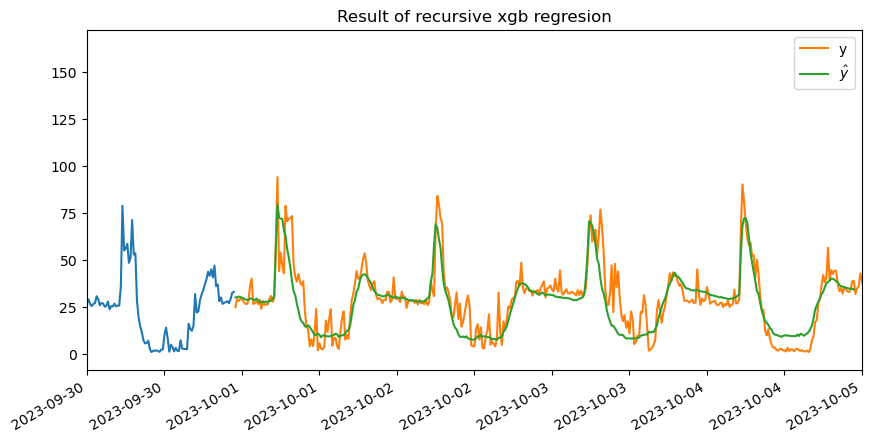

In [30]:
daysa = 96*4
yhat_test = forecaster.predict(steps=daysa)
# Save and display the plot
import matplotlib.ticker as ticker
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Result of recursive xgb regresion")
ax.plot(df_train['Date'],df_train['c_gen'])
# ax.plot(df_train['Time'],df_train['temp'])
ax.plot(df_test['Date'], df_test['c_gen'], label='y')
ax.plot(df_test['Date'][:daysa], yhat_test, label=r'$\hat{y}$')
# ax.plot(df_test['Time'][:daysa],df_test['temp'][:daysa], label='temp')
# ax.plot(df_after.Time.dt.tz_localize(None), df_after['PV'], label='After')

ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

ax.set_xlim(pd.Timestamp('2023-09-30'), pd.Timestamp('2023-10-05'))

# optional: minor ticks every 6 hours
# ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))

ax.legend()

fig.autofmt_xdate() # for rotation
fig.savefig(output_dir / "prediction_test.png", dpi=300, bbox_inches='tight')
plt.show()